# Semana 8 — Projeto Prático de Data Warehouse e Modelagem Dimensional

Mini Data Warehouse de e-commerce usando o dataset Olist.

## Objetivos

- Diferenciar OLTP e OLAP
- Executar ETL com Pandas
- Criar dimensões e tabela fato
- Identificar PK, FK e Surrogate Key
- Criar Star Schema
- Consultar o modelo com SQL
- Interpretar métricas de BI

## Arquivos necessários

Baixe no Kaggle o dataset Brazilian E-Commerce Public Dataset by Olist e coloque na pasta do notebook:

- olist_orders_dataset.csv
- olist_order_items_dataset.csv
- olist_customers_dataset.csv
- olist_products_dataset.csv
- product_category_name_translation.csv

In [9]:
import pandas as pd # Nosso processador 
import duckdb as db #Nosso SQL no projeto
import matplotlib.pyplot as plt #Ferramenta de gráficos

pd.set_option('display.max_columns', 100)

print("Iniciando o processo de análise de dados...")

Iniciando o processo de análise de dados...


# 1. Cenário de negócio

O diretor quer responder:

1. Qual foi o faturamento total?
2. Quais estados mais faturaram?
3. Quais categorias mais venderam?
4. Qual foi o ticket médio?
5. Como o faturamento evoluiu ao longo do tempo?

# 2. Extract — carregando fontes OLTP

In [10]:
pedidos = pd.read_csv('olist_orders_dataset.csv')
itens = pd.read_csv('olist_order_items_dataset.csv')
clientes = pd.read_csv('olist_customers_dataset.csv')
produtos = pd.read_csv('olist_products_dataset.csv')
traducao_categoria = pd.read_csv('product_category_name_translation.csv')

print('orders:', pedidos.shape)
print('items:', itens.shape)
print('customers:', clientes.shape)
print('products:', produtos.shape)
print('category_translation:', traducao_categoria.shape)

orders: (99441, 8)
items: (112650, 7)
customers: (99441, 5)
products: (32951, 9)
category_translation: (71, 2)


## Exercício 1 🟢 Fácil — OLTP

Responda:

1. Por que essas tabelas podem ser consideradas fontes OLTP?
Porquê são preenchidas manualmente no sistema da empresa.
2. Qual tabela registra o pedido?
olist_orders_dataset.csv
3. Qual tabela registra os itens de cada pedido?
olist_order_items_dataset.csv
4. Qual tabela descreve os clientes?
olist_customers_dataset.csv
5. Qual tabela descreve os produtos?
product_category_name_translation.csv

# 3. Análise exploratória inicial

In [11]:
pedidos.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [12]:
itens.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [13]:
clientes.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [14]:
produtos.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


## Exercício 2 🟢 Fácil — Explorando os dados

Use `.info()`, `.shape` e `.isnull().sum()` para investigar as tabelas.

In [15]:
# Investigue a tabela orders
# SUA RESPOSTA AQUI
print(f'Número de linhas em pedidos: {pedidos.shape[0]}')
print(f'Número de colunas em pedidos: {pedidos.shape[1]}')
pedidos.info()
pedidos.isnull().sum().sort_values(ascending=False)

Número de linhas em pedidos: 99441
Número de colunas em pedidos: 8
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


order_delivered_customer_date    2965
order_delivered_carrier_date     1783
order_approved_at                 160
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_estimated_delivery_date       0
dtype: int64

In [16]:
# Investigue a tabela items
# SUA RESPOSTA AQUI
print(f'Número de linhas em itens: {itens.shape[0]}')
print(f'Número de colunas em itens: {itens.shape[1]}')
itens.info()
itens.isnull().sum().sort_values(ascending=False)

Número de linhas em itens: 112650
Número de colunas em itens: 7
<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.0 MB


order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [17]:
# Investigue a tabela customers
# SUA RESPOSTA AQUI
print(f'Número de linhas em clientes: {clientes.shape[0]}')
print(f'Número de colunas em clientes: {clientes.shape[1]}')
clientes.info()
clientes.isnull().sum().sort_values(ascending=False)

Número de linhas em clientes: 99441
Número de colunas em clientes: 5
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [18]:
# Investigue a tabela products
# SUA RESPOSTA AQUI
print(f'Número de linhas em produtos: {produtos.shape[0]}')
print(f'Número de colunas em produtos: {produtos.shape[1]}')
produtos.info()
produtos.isnull().sum().sort_values(ascending=False)

Número de linhas em produtos: 32951
Número de colunas em produtos: 9
<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 2.3 MB


product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
product_id                      0
dtype: int64

# 4. Transform — tratamento dos dados

Transformações comuns: converter tipos, remover duplicidades, tratar nulos, padronizar nomes e criar colunas derivadas.

TABELA PEDIDOS

In [19]:
# Datas ajustadas para DataTime PEDIDOS
pedidos['order_purchase_timestamp'] = pd.to_datetime(pedidos['order_purchase_timestamp']) 
pedidos['order_approved_at'] = pd.to_datetime(pedidos['order_approved_at'])
pedidos['order_delivered_customer_date'] = pd.to_datetime(pedidos['order_delivered_customer_date'])
pedidos['order_estimated_delivery_date'] = pd.to_datetime(pedidos['order_estimated_delivery_date'])
pedidos['order_delivered_carrier_date'] = pd.to_datetime(pedidos['order_delivered_carrier_date'])

pedidos[['order_purchase_timestamp', 'order_approved_at','order_delivered_customer_date','order_estimated_delivery_date','order_delivered_carrier_date']].head()

,order_purchase_timestamp,order_approved_at,order_delivered_customer_date,order_estimated_delivery_date,order_delivered_carrier_date
0,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-10 21:25:13,2017-10-18,2017-10-04 19:55:00
1,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-08-07 15:27:45,2018-08-13,2018-07-26 14:31:00
2,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-17 18:06:29,2018-09-04,2018-08-08 13:50:00
3,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-12-02 00:28:42,2017-12-15,2017-11-22 13:39:59
4,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-16 18:17:02,2018-02-26,2018-02-14 19:46:34


In [20]:
#Tratando TABELA PEDIDOS
# Criar cópia da nossa tabela PEDIDOS
pedidos_id_int = pedidos.copy()


In [21]:
# Valores de colunas de tempo convertidas para tipos de variaves DataTime
pedidos_id_int.dtypes

order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

In [22]:
# Analisis de duplicatas considerando todas as colunas
print(f"Total de linhas duplicadas: {pedidos_id_int.duplicated().sum()}")

Total de linhas duplicadas: 0


In [23]:
# Ver se order_id tem duplicados
print(f"Order_id duplicados: {pedidos_id_int['order_id'].duplicated().sum()}")

Order_id duplicados: 0


In [24]:
# Ver nulos em cada coluna específica
colunas_pedidos_id_int = ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 
           'order_approved_at', 'order_delivered_carrier_date', 
           'order_delivered_customer_date', 'order_estimated_delivery_date']
# Mostrar nulos por coluna
print(pedidos_id_int[colunas_pedidos_id_int].isnull().sum())
nulos_estatisticas = pedidos_id_int[colunas_pedidos_id_int].isnull().sum()
# Estatisticas de nulos dentro da tabela dimensao pedidos
print(f'\n Estatisticas basica para tomada de decisao do tratamento dos nulos da tabela pedidos \n{nulos_estatisticas.describe().round(1)}')

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

 Estatisticas basica para tomada de decisao do tratamento dos nulos da tabela pedidos 
count       8.0
mean      613.5
std      1132.9
min         0.0
25%         0.0
50%         0.0
75%       565.8
max      2965.0
dtype: float64


As unicas colunas que apresentam dados nulos sao as colunas de data entao vamos a ajustar com a data anterior ao nulo para manter a sequencia ascendente da coluna

In [25]:
# Lista de colunas
colunas_datas = ['order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date']

# Aplicar forward fill no DataFrame (pedidos_id_int)
for col in colunas_datas:
    pedidos_id_int[col] = pedidos_id_int[col].ffill()

# Verificar resultado (nulos agora no DataFrame)
print(pedidos_id_int[colunas_datas].isnull().sum())

order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
dtype: int64


In [26]:
pedidos_limpos = pedidos_id_int
print(pedidos.dtypes)
print(pedidos_limpos['order_id'].head())

order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object
0    e481f51cbdc54678b7cc49136f2d6af7
1    53cdb2fc8bc7dce0b6741e2150273451
2    47770eb9100c2d0c44946d9cf07ec65d
3    949d5b44dbf5de918fe9c16f97b45f8a
4    ad21c59c0840e6cb83a9ceb5573f8159
Name: order_id, dtype: str


In [27]:
# Criar cópia com colunas traduzidas atraves de um diccionario com a funcao rename.
pedidos_traduzido = pedidos.rename(columns={
    'order_id': 'id_pedido',
    'customer_id': 'id_cliente',
    'order_status': 'status_pedido',
    'order_purchase_timestamp': 'data_compra',
    'order_approved_at': 'data_aprovacao',
    'order_delivered_carrier_date': 'data_envio_transportadora',
    'order_delivered_customer_date': 'data_entrega_cliente',
    'order_estimated_delivery_date': 'data_prevista_entrega'
})

print(pedidos_traduzido.columns.tolist())
print(pedidos_traduzido.dtypes)

['id_pedido', 'id_cliente', 'status_pedido', 'data_compra', 'data_aprovacao', 'data_envio_transportadora', 'data_entrega_cliente', 'data_prevista_entrega']
id_pedido                               str
id_cliente                              str
status_pedido                           str
data_compra                  datetime64[us]
data_aprovacao               datetime64[us]
data_envio_transportadora    datetime64[us]
data_entrega_cliente         datetime64[us]
data_prevista_entrega        datetime64[us]
dtype: object


In [28]:
tabela_pedidos = pedidos_traduzido.copy
print(f'Tabela pedidos tratada e 100% pronta novo nome tabela_pedidos')

Tabela pedidos tratada e 100% pronta novo nome tabela_pedidos


TABELA ITENS

In [55]:
# Ajustar da data da tabela Itens
itens['shipping_limit_date'] = pd.to_datetime(itens['shipping_limit_date'], errors='coerce') 
print(f'Coluna de shipping limit date transformada para o fortmato correto {itens['shipping_limit_date'].dtypes}')

print(f"Total de linhas duplicadas: {itens.duplicated().sum()}")
# Ver nulos por coluna
print(f'Conferencia de itens nulos \n{itens.isnull().sum()}')
itens.dtypes

# Criar cópia com colunas traduzidas
itens_traduzido = itens.rename(columns={
    'order_id': 'id_pedido',
    'order_item_id': 'id_item_pedido',
    'product_id': 'id_produto_itens',
    'seller_id': 'id_vendedor',
    'shipping_limit_date': 'data_limite_envio',
    'price': 'preco',
    'freight_value': 'valor_frete'
})

print(itens_traduzido.columns.tolist())
tabela_itens = itens_traduzido.copy
print(f'Tabela itens tratada e 100% pronta novo nome tabela_itens')

Coluna de shipping limit date transformada para o fortmato correto datetime64[us]
Total de linhas duplicadas: 0
Conferencia de itens nulos 
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64
['id_pedido', 'id_item_pedido', 'id_produto_itens', 'id_vendedor', 'data_limite_envio', 'preco', 'valor_frete']
Tabela itens tratada e 100% pronta novo nome tabela_itens


TABELA COSTUMERS

In [30]:
clientes.dtypes
print(f"Total de linhas duplicadas: {clientes.duplicated().sum()}")
# Ver nulos por coluna
print(f'Conferir si tem nulos\n{clientes.isnull().sum()}')
# Criar cópia com colunas traduzidas
clientes_traduzido = clientes.rename(columns={
    'customer_id': 'id_cliente',
    'customer_unique_id': 'id_cliente_unico',
    'customer_zip_code_prefix': 'prefixo_cep',
    'customer_city': 'cidade',
    'customer_state': 'estado'
})

print(clientes_traduzido.columns.tolist())
tabela_clientes = clientes_traduzido.copy
print(f'Tabela clientes tratada e 100% pronta novo nome tabela_clientes')

Total de linhas duplicadas: 0
Conferir si tem nulos
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64
['id_cliente', 'id_cliente_unico', 'prefixo_cep', 'cidade', 'estado']
Tabela clientes tratada e 100% pronta novo nome tabela_clientes


TABELA PRODUTOS

In [31]:
produtos_tratamento = produtos.copy()
produtos.dtypes
# Ver nulos por coluna
print(f'conferindo si tem nulos em produtos\n{produtos_tratamento.isnull().sum()}')
print(f"Total de linhas duplicadas: {produtos_tratamento.duplicated().sum()}")


conferindo si tem nulos em produtos
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64
Total de linhas duplicadas: 0


In [32]:
# Ver as colunas com nulos
colunas_nulos = ['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 
                 'product_photos_qty', 'product_weight_g', 'product_length_cm', 
                 'product_height_cm', 'product_width_cm']

for col in colunas_nulos:
    print(f"\n{'='*50}")
    print(f"COLUNA: {col}")
    print(f"{'='*50}")
    
    # Mostrar apenas as linhas onde a coluna é nula
    dados_nulos = produtos_tratamento[produtos_tratamento[col].isnull()][['product_id', col]]
    print(dados_nulos.head(10))
    print(f"Total de linhas com nulos: {len(dados_nulos)}")


COLUNA: product_id
Empty DataFrame
Columns: [product_id, product_id]
Index: []
Total de linhas com nulos: 0

COLUNA: product_category_name
                           product_id product_category_name
105  a41e356c76fab66334f36de622ecbd3a                   NaN
128  d8dee61c2034d6d075997acef1870e9b                   NaN
145  56139431d72cd51f19eb9f7dae4d1617                   NaN
154  46b48281eb6d663ced748f324108c733                   NaN
197  5fb61f482620cb672f5e586bb132eae9                   NaN
244  e10758160da97891c2fdcbc35f0f031d                   NaN
294  39e3b9b12cd0bf8ee681bbc1c130feb5                   NaN
299  794de06c32a626a5692ff50e4985d36f                   NaN
347  7af3e2da474486a3519b0cba9dea8ad9                   NaN
428  629beb8e7317703dcc5f35b5463fd20e                   NaN
Total de linhas com nulos: 610

COLUNA: product_name_lenght
                           product_id  product_name_lenght
105  a41e356c76fab66334f36de622ecbd3a                  NaN
128  d8dee61c2034d6d07

In [33]:
# Para as 3 primeiras colunas (610 nulos)
colunas_610 = ['product_category_name', 'product_name_lenght', 
               'product_description_lenght']

for col in colunas_610:
    produtos[col] = produtos[col].fillna('Desconhecido' if col == 'product_category_name' else 0)

# Para as colunas de medidas (2 nulos)
colunas_medidas = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

for col in colunas_medidas:
    produtos[col] = produtos[col].fillna(produtos[col].median())

# Verificar se resolveu
print(produtos[colunas_610 + colunas_medidas].isnull().sum())

product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64


In [34]:
# Ver a mediana antes de aplicar
print(f"Mediana de product_photos_qty: {produtos['product_photos_qty'].median()}")
print(produtos['product_photos_qty'].isnull().sum())

Mediana de product_photos_qty: 1.0
610


In [45]:
produtos_tratamento.rename(columns={'product_id': 'id_produto',
    'product_category_name': 'categoria_produto',
    'product_name_lenght': 'tamanho_nome_produto',
    'product_description_lenght': 'tamanho_descricao_produto',
    'product_weight_g': 'peso_gramas',
    'product_length_cm': 'comprimento_cm',
    'product_height_cm': 'altura_cm',
    'product_width_cm': 'largura_cm',
    'product_photos_qty': 'quantidade_fotos'
}, inplace=True)

# Verificar
print(produtos.columns.tolist())
tabela_produtos = produtos_tratamento.copy()
print(f'Tabela PRODUTOS tratada e 100% pronta com novo nome tabela_produtos')
print(produtos.head())
  

['id_produto', 'categoria_produto', 'tamanho_nome_produto', 'tamanho_descricao_produto', 'quantidade_fotos', 'peso_gramas', 'comprimento_cm', 'altura_cm', 'largura_cm']
Tabela PRODUTOS tratada e 100% pronta com novo nome tabela_produtos
                         id_produto      categoria_produto  \
0  1e9e8ef04dbcff4541ed26657ea517e5             perfumaria   
1  3aa071139cb16b67ca9e5dea641aaa2f                  artes   
2  96bd76ec8810374ed1b65e291975717f          esporte_lazer   
3  cef67bcfe19066a932b7673e239eb23d                  bebes   
4  9dc1a7de274444849c219cff195d0b71  utilidades_domesticas   

   tamanho_nome_produto  tamanho_descricao_produto  quantidade_fotos  \
0                  40.0                      287.0               1.0   
1                  44.0                      276.0               1.0   
2                  46.0                      250.0               1.0   
3                  27.0                      261.0               1.0   
4                  37.0       

## Exercício 3 🟢 Fácil — Criando atributos de tempo

Crie as colunas `ano`, `mes`, `dia`, `trimestre` e `ano_mes` a partir de `order_purchase_timestamp`.

In [36]:
# Recriar a partir do original
tabela_pedidos = pedidos_traduzido.copy()

# Verificar o tipo agora
print(type(tabela_pedidos))

<class 'pandas.DataFrame'>


In [37]:
# SUA RESPOSTA AQUI
# Conferir formatacao correta
# Garantir que a coluna de data está no formato datetime
tabela_pedidos['data_compra'] = pd.to_datetime(tabela_pedidos['data_compra'])

# Criar as colunas
tabela_pedidos['ano'] = tabela_pedidos['data_compra'].dt.year
tabela_pedidos['mes'] = tabela_pedidos['data_compra'].dt.month
tabela_pedidos['dia'] = tabela_pedidos['data_compra'].dt.day
tabela_pedidos['trimestre'] = tabela_pedidos['data_compra'].dt.quarter
tabela_pedidos['ano_mes'] = tabela_pedidos['data_compra'].dt.to_period('M')

# Verificar resultado
print(tabela_pedidos[['data_compra', 'ano', 'mes', 'dia', 'trimestre', 'ano_mes']].head())


          data_compra   ano  mes  dia  trimestre  ano_mes
0 2017-10-02 10:56:33  2017   10    2          4  2017-10
1 2018-07-24 20:41:37  2018    7   24          3  2018-07
2 2018-08-08 08:38:49  2018    8    8          3  2018-08
3 2017-11-18 19:28:06  2017   11   18          4  2017-11
4 2018-02-13 21:18:39  2018    2   13          1  2018-02


## Exercício 4 🟢 Fácil — Remoção de duplicidades

Verifique se existem duplicidades nas tabelas principais e remova-as.

In [38]:
# SUA RESPOSTA AQUI
# 1. TABELA PEDIDOS
print("="*40)
print("TABELA PEDIDOS")
print("="*40)
print(f"Linhas duplicadas: {tabela_pedidos.duplicated().sum()}")

# 2. TABELA ITENS
# Recriar tabela_itens
tabela_itens = itens.copy()
print("TABELA ITENS")
print("="*40)
print(f"Linhas duplicadas: {tabela_itens.duplicated().sum()}")

# 3. TABELA PRODUTOS
print("\n" + "="*40)
print("TABELA PRODUTOS")
print("="*40)
print(f"Linhas duplicadas: {produtos.duplicated().sum()}")

# 4. TABELA CLIENTES
# Recriar tabela_CLIENTES

tabela_clientes = clientes_traduzido.copy()
print("\n" + "="*40)
print("TABELA CLIENTES")
print("="*40)
print(f"Linhas duplicadas: {tabela_clientes.duplicated().sum()}")


TABELA PEDIDOS


Linhas duplicadas: 0
TABELA ITENS
Linhas duplicadas: 0

TABELA PRODUTOS
Linhas duplicadas: 0

TABELA CLIENTES
Linhas duplicadas: 0


## Exercício 5 🟡 Médio — Filtro de pedidos válidos

Considere apenas pedidos com status `delivered` e crie `produtos_entregue`.

In [39]:
# SUA RESPOSTA AQUI
# Filtrar apenas pedidos com status 'delivered'
produtos_entregue = tabela_pedidos[tabela_pedidos['status_pedido'] == 'delivered']

# Verificar resultado
print(f"Total de pedidos: {len(tabela_pedidos)}")
print(f"Pedidos entregues: {len(produtos_entregue)}")
print(f"Percentual: {len(produtos_entregue)/len(tabela_pedidos)*100:.2f}%")

# Ver primeiras linhas
print(produtos_entregue[['id_pedido', 'status_pedido']].head())


Total de pedidos: 99441
Pedidos entregues: 96478
Percentual: 97.02%
                          id_pedido status_pedido
0  e481f51cbdc54678b7cc49136f2d6af7     delivered
1  53cdb2fc8bc7dce0b6741e2150273451     delivered
2  47770eb9100c2d0c44946d9cf07ec65d     delivered
3  949d5b44dbf5de918fe9c16f97b45f8a     delivered
4  ad21c59c0840e6cb83a9ceb5573f8159     delivered


# 5. Modelagem dimensional

Modelo esperado:

```text
dim_cliente
     |
dim_produto -- fato_vendas -- dim_tempo
```

A tabela fato guarda eventos mensuráveis. As dimensões guardam contexto.

# 6. Criando a dimensão cliente

In [40]:
dim_cliente = tabela_clientes.copy()
dim_cliente = dim_cliente[[
    'id_cliente',
    'cidade',
    'estado',
    'prefixo_cep'
]]
dim_cliente.head()

,id_cliente,cidade,estado,prefixo_cep
0,06b8999e2fba1a1fbc88172c00ba8bc7,franca,SP,14409
1,18955e83d337fd6b2def6b18a428ac77,sao bernardo do campo,SP,9790
2,4e7b3e00288586ebd08712fdd0374a03,sao paulo,SP,1151
3,b2b6027bc5c5109e529d4dc6358b12c3,mogi das cruzes,SP,8775
4,4f2d8ab171c80ec8364f7c12e35b23ad,campinas,SP,13056


## Exercício 6 🟡 Médio — PK, SK e chave natural

1. Qual coluna é a Surrogate Key da dimensão cliente?
['cliente_sk']
2. Qual coluna veio do sistema de origem?
id_cliente
3. Por que não usar CPF, e-mail ou código da origem como PK física do DW?
É um dado sensivel que nao pode ser usado por causa da lei LPG por isso é criada a SK

# 7. Criando a dimensão produto

In [46]:
print(tabela_produtos.columns.tolist())

['id_produto', 'categoria_produto', 'tamanho_nome_produto', 'tamanho_descricao_produto', 'quantidade_fotos', 'peso_gramas', 'comprimento_cm', 'altura_cm', 'largura_cm']


In [47]:
dim_produto = tabela_produtos.copy()
dim_produto = dim_produto[[
    'id_produto',
    'categoria_produto',
]]
dim_produto.head()

,id_produto,categoria_produto
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria
1,3aa071139cb16b67ca9e5dea641aaa2f,artes
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer
3,cef67bcfe19066a932b7673e239eb23d,bebes
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas


## Exercício 7 🟡 Médio — Star Schema vs Snowflake

1. Esse modelo se parece mais com Star Schema ou Snowflake?
Star Schema porquê é um modelo simples sem muitas dimensoões e colunas
2. Como ficaria se categoria fosse uma tabela separada?
Ficaria mais próximo a um modelo SnowFlake
3. Qual opção costuma ser mais simples para Power BI?
Star Schema mais focado a visualização para pessoas que somente precisam entender o que esta acontencendo em termos rápidos.

# 8. Criando a dimensão tempo

In [112]:
#verifica se tem duplicidade de data e copia a tabela para criar a dimensão tempo

dim_tempo = produtos_entregue[['data_compra']].drop_duplicates().copy()

### Crie as colunas necessárias para a dimensão tempo
dim_tempo['data'] = dim_tempo['data_compra'].dt.date #cria a coluna data apenas com a data, sem o horário
dim_tempo['ano'] = dim_tempo['data_compra'].dt.year #cria a coluna ano apenas com o ano da data
dim_tempo['mes'] = dim_tempo['data_compra'].dt.month #cria a coluna mes apenas com o mês da data
dim_tempo['dia'] = dim_tempo['data_compra'].dt.day #cria a coluna dia apenas com o dia da data
dim_tempo['trimestre'] = dim_tempo['data_compra'].dt.quarter #cria a coluna trimestre apenas com o trimestre da data


dim_tempo['ano_mes'] = dim_tempo['data_compra'].dt.to_period('M').astype(str) #cria a coluna ano_mes apenas com o ano e o mês da data, no formato "YYYY-MM"
dim_tempo = dim_tempo.drop_duplicates('data').reset_index(drop=True) #remove as linhas duplicadas com base na coluna data e reseta o índice
dim_tempo['tempo_sk'] = dim_tempo.index + 1 #cria a coluna tempo_sk com os valores sequenciais
dim_tempo = dim_tempo[['tempo_sk', 'data', 'ano', 'mes', 'dia', 'trimestre', 'ano_mes']] #reordena as colunas da dimensão tempo
dim_tempo.head() #exibe as primeiras linhas da dimensão tempo

,tempo_sk,data,ano,mes,dia,trimestre,ano_mes
0,1,2017-10-02,2017,10,2,4,2017-10
1,2,2018-07-24,2018,7,24,3,2018-07
2,3,2018-08-08,2018,8,8,3,2018-08
3,4,2017-11-18,2017,11,18,4,2017-11
4,5,2018-02-13,2018,2,13,1,2018-02


## Exercício 8 🟡 Médio — Dimensão tempo

1. Por que uma dimensão tempo é útil em BI?
Para saber mais aprofundadamente o que esta acontencendo com a empresa em momentos especificos.
2. Que análises ela permite?
ano, mes, trimestre.
3. Qual coluna é a SK da dimensão tempo?
tempo_sk 

# 9. Criando a tabela fato

Evento: um item vendido dentro de um pedido.

Granularidade: uma linha por item vendido em um pedido.

In [61]:
tabela_itens = itens_traduzido.copy()
print(tabela_itens.columns.tolist())
print(tabela_itens.dtypes)

['id_pedido', 'id_item_pedido', 'id_produto_itens', 'id_vendedor', 'data_limite_envio', 'preco', 'valor_frete']
id_pedido                       str
id_item_pedido                int64
id_produto_itens                str
id_vendedor                     str
data_limite_envio    datetime64[us]
preco                       float64
valor_frete                 float64
dtype: object


In [64]:
# Criando fato_vendas com dados traduzidos
fato_vendas = tabela_itens[['id_pedido', 'id_item_pedido', 'id_produto_itens', 'preco', 'valor_frete']].copy()

fato_vendas = fato_vendas.merge(
    produtos_entregue[['id_pedido', 'id_cliente', 'data_compra']],
    on='id_pedido',
    how='inner'
)

print(fato_vendas.head())

                          id_pedido  id_item_pedido  \
0  00010242fe8c5a6d1ba2dd792cb16214               1   
1  00018f77f2f0320c557190d7a144bdd3               1   
2  000229ec398224ef6ca0657da4fc703e               1   
3  00024acbcdf0a6daa1e931b038114c75               1   
4  00042b26cf59d7ce69dfabb4e55b4fd9               1   

                   id_produto_itens   preco  valor_frete  \
0  4244733e06e7ecb4970a6e2683c13e61   58.90        13.29   
1  e5f2d52b802189ee658865ca93d83a8f  239.90        19.93   
2  c777355d18b72b67abbeef9df44fd0fd  199.00        17.87   
3  7634da152a4610f1595efa32f14722fc   12.99        12.79   
4  ac6c3623068f30de03045865e4e10089  199.90        18.14   

                         id_cliente         data_compra  
0  3ce436f183e68e07877b285a838db11a 2017-09-13 08:59:02  
1  f6dd3ec061db4e3987629fe6b26e5cce 2017-04-26 10:53:06  
2  6489ae5e4333f3693df5ad4372dab6d3 2018-01-14 14:33:31  
3  d4eb9395c8c0431ee92fce09860c5a06 2018-08-08 10:00:35  
4  58dbd0b2d70206b

## Exercício 9 🟡 Médio — Relacionando fato e dimensões

Complete a construção da `fato_vendas` trazendo `cliente_sk`, `produto_sk` e `tempo_sk`.

In [66]:
#Processo previo para obter colunas faltantes para a tabela fato_vendas
# Criar cliente_sk na dim_cliente
dim_cliente['cliente_sk'] = dim_cliente.index + 1

# Criar produto_sk na dim_produto
dim_produto['produto_sk'] = dim_produto.index + 1

# Verificar se criou
print(dim_cliente[['id_cliente', 'cliente_sk']].head())
print(dim_produto[['id_produto', 'produto_sk']].head())

                         id_cliente  cliente_sk
0  06b8999e2fba1a1fbc88172c00ba8bc7           1
1  18955e83d337fd6b2def6b18a428ac77           2
2  4e7b3e00288586ebd08712fdd0374a03           3
3  b2b6027bc5c5109e529d4dc6358b12c3           4
4  4f2d8ab171c80ec8364f7c12e35b23ad           5
                         id_produto  produto_sk
0  1e9e8ef04dbcff4541ed26657ea517e5           1
1  3aa071139cb16b67ca9e5dea641aaa2f           2
2  96bd76ec8810374ed1b65e291975717f           3
3  cef67bcfe19066a932b7673e239eb23d           4
4  9dc1a7de274444849c219cff195d0b71           5


In [76]:
# Garantir que a coluna tempo_sk existe
if 'tempo_sk' not in fato_vendas.columns:
    print("Criando tempo_sk...")
    dim_tempo = fato_vendas[['data_compra']].drop_duplicates().copy()
    dim_tempo['tempo_sk'] = dim_tempo.index + 1
    
    fato_vendas = fato_vendas.merge(
        dim_tempo[['data_compra', 'tempo_sk']],
        on='data_compra',
        how='left'
    )

# Verificar
print(fato_vendas[['id_pedido', 'tempo_sk']].head())

Criando tempo_sk...
                          id_pedido  tempo_sk
0  00010242fe8c5a6d1ba2dd792cb16214         1
1  00018f77f2f0320c557190d7a144bdd3         2
2  000229ec398224ef6ca0657da4fc703e         3
3  00024acbcdf0a6daa1e931b038114c75         4
4  00042b26cf59d7ce69dfabb4e55b4fd9         5


In [83]:
# SUA RESPOSTA AQUI
# Remover colunas SK antigas
colunas_para_remover = ['cliente_sk', 'produto_sk', 'tempo_sk', 'id_produto']
for col in colunas_para_remover:
    if col in fato_vendas.columns:
        fato_vendas = fato_vendas.drop(columns=[col])

# 1. Cliente SK
fato_vendas = fato_vendas.merge(
    dim_cliente[['id_cliente', 'cliente_sk']],
    on='id_cliente',
    how='left'
)

# 2. Produto SK (com suffixes)
fato_vendas = fato_vendas.merge(
    dim_produto[['id_produto', 'produto_sk']],
    left_on='id_produto_itens',
    right_on='id_produto',
    how='left',
    suffixes=('', '_dim')
)

# 3. Tempo SK
fato_vendas = fato_vendas.merge(
    dim_tempo[['data_compra', 'tempo_sk']],
    on='data_compra',
    how='left'
)

# Selecionar colunas finais
fato_vendas_final = fato_vendas[[
    'id_pedido',
    'id_item_pedido',
    'cliente_sk',
    'produto_sk',
    'tempo_sk',
    'preco',
    'valor_frete'
]]

print(fato_vendas_final.head())


                          id_pedido  id_item_pedido  cliente_sk  produto_sk  \
0  00010242fe8c5a6d1ba2dd792cb16214               1       65558       25866   
1  00018f77f2f0320c557190d7a144bdd3               1       34266       27231   
2  000229ec398224ef6ca0657da4fc703e               1       34956       22625   
3  00024acbcdf0a6daa1e931b038114c75               1       51764       15404   
4  00042b26cf59d7ce69dfabb4e55b4fd9               1        7603        8863   

   tempo_sk   preco  valor_frete  
0         1   58.90        13.29  
1         2  239.90        19.93  
2         3  199.00        17.87  
3         4   12.99        12.79  
4         5  199.90        18.14  


## Exercício 10 🟡 Médio — Métricas da fato

Crie `valor_produto`, `valor_frete` e `valor_total`.

In [84]:
# SUA RESPOSTA AQUI
# Criar as colunas de valor
fato_vendas_final['valor_produto'] = fato_vendas_final['preco']  # já é o valor do produto (unitário)
fato_vendas_final['valor_frete'] = fato_vendas_final['valor_frete']  # já existe
fato_vendas_final['valor_total'] = fato_vendas_final['valor_produto'] + fato_vendas_final['valor_frete']

# Verificar
print(fato_vendas_final[['preco', 'valor_produto', 'valor_frete', 'valor_total']].head())

    preco  valor_produto  valor_frete  valor_total
0   58.90          58.90        13.29        72.19
1  239.90         239.90        19.93       259.83
2  199.00         199.00        17.87       216.87
3   12.99          12.99        12.79        25.78
4  199.90         199.90        18.14       218.04


## Exercício 11 🔴 Difícil — Fato final

Deixe a fato com: `order_id`, `order_item_id`, `cliente_sk`, `produto_sk`, `tempo_sk`, `valor_produto`, `valor_frete`, `valor_total`.

Depois, crie `venda_sk`.

In [85]:
# SUA RESPOSTA AQUI
# 1. Selecionar as colunas na ordem desejada
fato_vendas_final = fato_vendas_final[[
    'id_pedido',
    'id_item_pedido',
    'cliente_sk',
    'produto_sk',
    'tempo_sk',
    'valor_produto',
    'valor_frete',
    'valor_total'
]]

# 2. Criar a chave artificial venda_sk
fato_vendas_final['venda_sk'] = fato_vendas_final.index + 1

# 3. Reorganizar com venda_sk como primeira coluna
fato_vendas_final = fato_vendas_final[[
    'venda_sk',
    'id_pedido',
    'id_item_pedido',
    'cliente_sk',
    'produto_sk',
    'tempo_sk',
    'valor_produto',
    'valor_frete',
    'valor_total'
]]

# 4. Verificar
print(fato_vendas_final.head())
print(f"\nColunas: {fato_vendas_final.columns.tolist()}")

   venda_sk                         id_pedido  id_item_pedido  cliente_sk  \
0         1  00010242fe8c5a6d1ba2dd792cb16214               1       65558   
1         2  00018f77f2f0320c557190d7a144bdd3               1       34266   
2         3  000229ec398224ef6ca0657da4fc703e               1       34956   
3         4  00024acbcdf0a6daa1e931b038114c75               1       51764   
4         5  00042b26cf59d7ce69dfabb4e55b4fd9               1        7603   

   produto_sk  tempo_sk  valor_produto  valor_frete  valor_total  
0       25866         1          58.90        13.29        72.19  
1       27231         2         239.90        19.93       259.83  
2       22625         3         199.00        17.87       216.87  
3       15404         4          12.99        12.79        25.78  
4        8863         5         199.90        18.14       218.04  

Colunas: ['venda_sk', 'id_pedido', 'id_item_pedido', 'cliente_sk', 'produto_sk', 'tempo_sk', 'valor_produto', 'valor_frete', 'valor_to

# 10. Validando o Star Schema

## Exercício 12 🔴 Difícil — Documentação do modelo

| Tabela | Tipo | PK | FK | Descrição |
|---|---|---|---|---|
| dim_cliente | dimensão  | cliente_sk |  | Dados dos clientes: id_cliente, cidade, estado, prefixo_cep |
| dim_produto | dimensão  | produto_sk |  | Dados dos produtos: id_produto, categoria_produto |
| dim_tempo | dimensão | tempo_sk |  | Dados temporais: data_compra, ano, mes, dia, trimestre, ano_mes |
| fato_vendas | metricas | venda_sk | cliente_sk, produto_sk, tempo_sk | Eventos de venda: id_pedido, id_item_pedido, valor_produto, valor_frete, valor_total |

# 11. SQL Analítico com DuckDB

In [117]:
con = db.connect()
con.register('dim_cliente', dim_cliente) # registra a dimensão cliente no banco de dados
con.register('dim_produto', dim_produto) # registra a dimensão produto no banco de dados
con.register('dim_tempo', dim_tempo) # registra a dimensão tempo no banco de dados
con.register('fato_vendas', fato_vendas_final) # registra a tabela fato vendas no banco de dados

In [91]:
#Criamos uma função para ajustar a moeda
def formatar_moeda(valor):
    """Formata um valor numérico para moeda brasileira"""
    return f"R$ {valor:,.2f}".replace(',', 'v').replace('.', ',').replace('v', '.')

## Consulta exemplo — Faturamento total

In [94]:
# consulta para calcular o faturamento total da loja, somando a coluna valor_total da tabela fato_vendas
# Usar a função
faturamento = con.sql("""
SELECT SUM(valor_total) AS faturamento_total
FROM fato_vendas
""").df()

print(f"Faturamento total: {formatar_moeda(faturamento['faturamento_total'].iloc[0])}")

Faturamento total: R$ 15.419.773,75


## Exercício 13 🟡 Médio — Faturamento por estado

In [101]:
faturamento_estado = con.sql("""
SELECT 
    dc.estado,
    SUM(fv.valor_total) AS faturamento_total
FROM fato_vendas fv
JOIN dim_cliente dc ON fv.cliente_sk = dc.cliente_sk
GROUP BY dc.estado
ORDER BY faturamento_total DESC
""").df()

print(faturamento_estado)

   estado  faturamento_total
0      SP         5769703.15
1      RJ         2055401.57
2      MG         1818891.67
3      RS          861472.79
4      PR          781708.80
5      SC          595127.78
6      BA          591137.81
7      DF          346123.35
8      GO          334212.35
9      ES          317657.93
10     PE          308972.05
11     CE          266436.77
12     PA          212023.57
13     MT          181224.42
14     MA          147803.55
15     PB          137838.55
16     MS          134367.55
17     PI          105178.19
18     RN          100714.78
19     AL           94172.49
20     SE           70289.13
21     TO           60007.37
22     RO           56966.00
23     AM           27585.47
24     AC           19575.33
25     AP           16141.81
26     RR            9039.52


## Exercício 14 🟡 Médio — Top 10 categorias

In [106]:
dim_produto = con.sql("""
SELECT
    dp.categoria_produto,
    SUM(fv.valor_total) AS faturamento_total
FROM fato_vendas fv
JOIN dim_produto dp ON fv.produto_sk = dp.produto_sk
GROUP BY dp.categoria_produto
ORDER BY faturamento_total DESC
""").df()

print(dim_produto.head(10))

        categoria_produto  faturamento_total
0            beleza_saude         1412089.53
1      relogios_presentes         1264333.12
2         cama_mesa_banho         1225209.26
3           esporte_lazer         1118256.91
4  informatica_acessorios         1032723.77
5        moveis_decoracao          880329.92
6   utilidades_domesticas          758392.25
7              cool_stuff          691680.89
8              automotivo          669454.75
9      ferramentas_jardim          567145.68


## Exercício 15 🔴 Difícil — Ticket médio por estado

In [108]:
ticket_medio_estado = con.sql("""
SELECT 
    dc.estado,
    SUM(fv.valor_total) / COUNT(DISTINCT fv.id_pedido) AS ticket_medio
FROM fato_vendas fv
JOIN dim_cliente dc ON fv.cliente_sk = dc.cliente_sk
GROUP BY dc.estado
ORDER BY ticket_medio DESC
""").df()

print(ticket_medio_estado.round(2))

   estado  ticket_medio
0      PB        266.61
1      AC        244.69
2      AP        240.92
3      AL        237.21
4      RO        234.43
5      PA        224.13
6      PI        220.96
7      RR        220.48
8      TO        219.01
9      RN        212.48
10     SE        209.82
11     CE        208.32
12     MA        206.14
13     MT        204.54
14     PE        193.96
15     MS        191.68
16     AM        190.24
17     BA        181.55
18     GO        170.78
19     SC        167.83
20     RJ        166.43
21     DF        166.41
22     RS        161.17
23     MG        160.20
24     ES        159.23
25     PR        158.79
26     SP        142.46


## Exercício 16 🔴 Difícil — Evolução mensal de faturamento

In [119]:
evolucao_mensal = con.sql("""
SELECT 
    dt.ano_mes,
    SUM(fv.valor_total) AS faturamento_mensal
FROM fato_vendas fv
JOIN dim_tempo dt ON fv.tempo_sk = dt.tempo_sk
GROUP BY dt.ano_mes
ORDER BY dt.ano_mes DESC
""").df()

print(evolucao_mensal)

    ano_mes  faturamento_mensal
0   2018-08             4405.74
1   2018-07             3612.69
2   2018-06             3330.47
3   2018-05             3944.11
4   2018-04             2977.38
5   2018-03             3408.38
6   2018-02             3570.71
7   2018-01             4843.24
8   2017-12             3864.14
9   2017-11             4946.54
10  2017-10             5969.21
11  2017-09             4072.32
12  2017-08             2449.97
13  2017-07             3763.71
14  2017-06             4907.19
15  2017-05             3302.21
16  2017-04             2930.35
17  2017-03             3597.64
18  2017-02             5378.94
19  2017-01             4215.73
20  2016-12               84.32
21  2016-10             1065.77
22  2016-09               81.16


# 12. Visualização simples

In [121]:
faturamento_mensal = con.sql("""
SELECT t.ano_mes, SUM(f.valor_total) AS faturamento_total
FROM fato_vendas f
JOIN dim_tempo t ON f.tempo_sk = t.tempo_sk
GROUP BY t.ano_mes
ORDER BY t.ano_mes ASC
""").df()
faturamento_mensal.head()

,ano_mes,faturamento_total
0,2016-09,81.16
1,2016-10,1065.77
2,2016-12,84.32
3,2017-01,4215.73
4,2017-02,5378.94


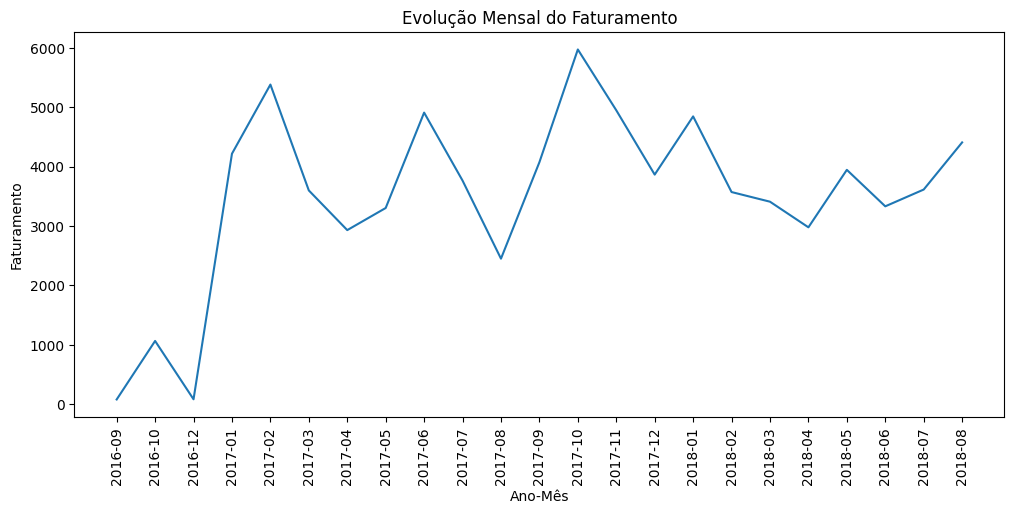

In [122]:
plt.figure(figsize=(12,5))
plt.plot(faturamento_mensal['ano_mes'], faturamento_mensal['faturamento_total'])
plt.xticks(rotation=90)
plt.title('Evolução Mensal do Faturamento')
plt.xlabel('Ano-Mês')
plt.ylabel('Faturamento')
plt.show()

## Exercício 17 🔴 Difícil — Visualização

Crie um gráfico de barras com o faturamento por estado.

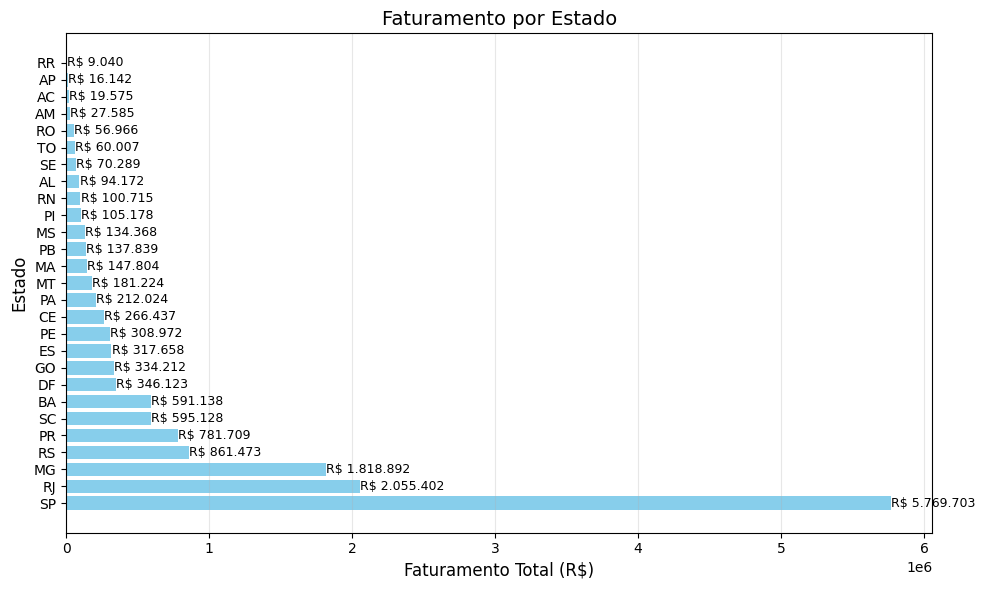

In [123]:
# SUA RESPOSTA AQUI
plt.figure(figsize=(10, 6))
plt.barh(faturamento_estado['estado'], faturamento_estado['faturamento_total'], color='skyblue')
plt.title('Faturamento por Estado', fontsize=14)
plt.xlabel('Faturamento Total (R$)', fontsize=12)
plt.ylabel('Estado', fontsize=12)
plt.grid(axis='x', alpha=0.3)

# Adicionar valores
for i, v in enumerate(faturamento_estado['faturamento_total']):
    plt.text(v + 1000, i, f'R$ {v:,.0f}'.replace(',', '.'), va='center', fontsize=9)

plt.tight_layout()
plt.show()

# 13. Snowflake Schema — desafio conceitual

No modelo atual, `dim_produto` possui categoria dentro da própria dimensão.

Em Snowflake, poderíamos separar `dim_produto` e `dim_categoria`.

## Exercício 18 🔴 Difícil

1. Qual vantagem do Snowflake nesse caso?
Mais detalhe nos processos que a empresa esta gerando em todos os setores
2. Qual desvantagem?
Maior processamento de dados leva a mais lentidão e maior despesa para contratar DataWhere House
3. Para Power BI, você escolheria Star ou Snowflake? Justifique.
Star Schema. Modelagem mais claro e conciso para que a gerencia tome as decisões melhor informadas.

# 14. Desafio Final — Caso Executivo

O diretor pediu uma análise com:

1. Faturamento total
2. Top 5 estados por faturamento
3. Top 10 categorias
4. Ticket médio geral
5. Evolução mensal do faturamento
6. Explicação do modelo dimensional usado
7. Justificativa de por que a solução é OLAP

## Entrega

- Notebook preenchido
- Print ou desenho do Star Schema
- Resposta executiva com 5 a 10 linhas